## The kNN Model
The definition of nearest neighbors is based on the computation of the Euclidean distance from the new data point to each of the existing data points.

We’ll be working with a dataset of hourly traffic volumes from the Interstate 94. You can find this dataset on the UCI machine learning repository:  
***`https://archive.ics.uci.edu/ml/datasets/Metro+Interstate+Traffic+Volume`***

In [1]:
import pandas as pd

data = pd.read_csv('../database/metro+interstate+traffic+volume/Metro_Interstate_Traffic_Volume.csv/Metro_Interstate_Traffic_Volume.csv')

data

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


In this data, you’ll find that it has hourly traffic volume, together with some weather data and information about holidays. For the present example, let’s avoid depending on weather data and do a forecast based on seasonality and holidays. After all, we could imagine that traffic depends heavily on the time of day, weekdays, and holidays.

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [4]:
#Feature engineering to create the additional explanatory variables
data['year'] = data['date_time'].apply(lambda x: x[:4])
data['month'] = data['date_time'].apply(lambda x: x[5:7])
data['weekday'] = pd.to_datetime(data['date_time']).apply(lambda x: x.weekday())
data['hour'] = pd.to_datetime(data['date_time']).apply(lambda x: x.hour)
data['isholiday'] = (data['holiday'] == 'None').apply(float) # This will make sure the NaN in the holiday data becomes 0.0
data

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,year,month,weekday,hour,isholiday
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,2012,10,1,9,0.0
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,2012,10,1,10,0.0
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,2012,10,1,11,0.0
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,2012,10,1,12,0.0
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,2012,10,1,13,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543,2018,09,6,19,0.0
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781,2018,09,6,20,0.0
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159,2018,09,6,21,0.0
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450,2018,09,6,22,0.0


In [7]:
# Creating the train-test split and computing the R2 of the default model

# Create objects X and y
X = data[['year', 'month', 'weekday', 'hour', 'isholiday']]
y = data['traffic_volume']

# Create Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100, random_state=12345, shuffle=False)

from sklearn.neighbors import KNeighborsRegressor
my_kn = KNeighborsRegressor() ## default k=5
my_kn.fit(X_train, y_train)
fcst = my_kn.predict(X_test)

from sklearn.metrics import r2_score
print("train r2score: ",r2_score(list(y_train), list(my_kn.predict(X_train))))
print("test r2score: ",r2_score(list(y_test), list(fcst)))

train r2score:  0.9546202670525249
test r2score:  0.9725269542830707


In [9]:
X_test ## we checked to confirm how test_size=100 works. This confirms that test_size can take values between 0-1 (percentage) and integers

,year,month,weekday,hour,isholiday
48104,2018,09,3,0,0.0
48105,2018,09,3,1,0.0
48106,2018,09,3,2,0.0
48107,2018,09,3,3,0.0
48108,2018,09,3,4,0.0
...,...,...,...,...,...
48199,2018,09,6,19,0.0
48200,2018,09,6,20,0.0
48201,2018,09,6,21,0.0
48202,2018,09,6,22,0.0


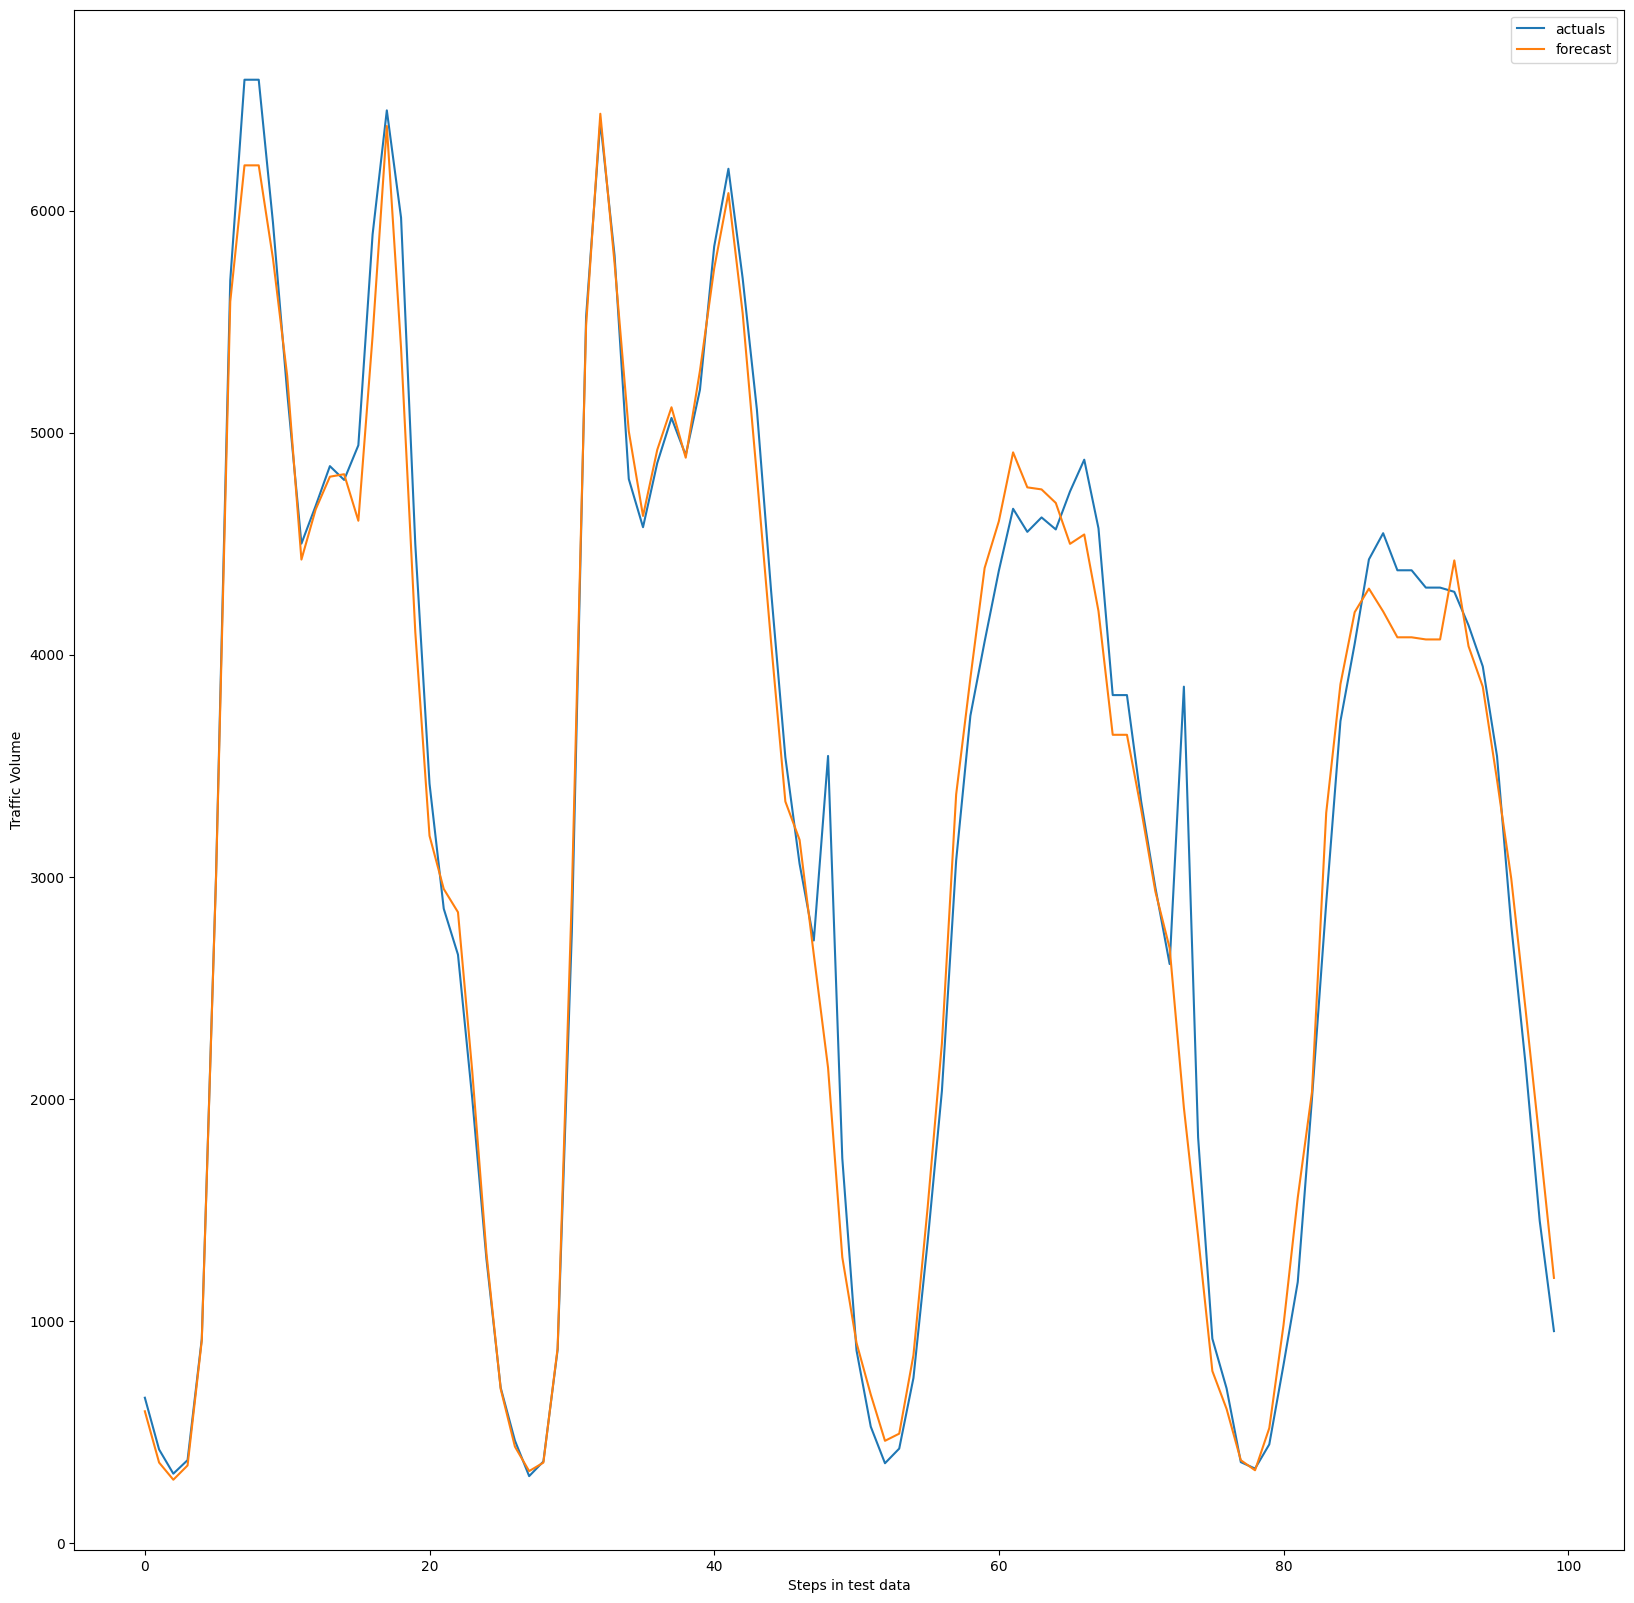

In [10]:
# Creating a plot on the data of the test set
import matplotlib.pyplot as plt

plt.figure(figsize=(20,20))
plt.plot(list(y_test))
plt.plot(list(fcst))
plt.legend(['actuals', 'forecast'])
plt.ylabel('Traffic Volume')
plt.xlabel('Steps in test data')
plt.show()

THis is an excellent performance.

In [11]:
# Adding a grid search cross-validation to the kNN model
from sklearn.model_selection import GridSearchCV

params={'n_neighbors':[2, 4, 6, 8, 10, 12]}
knn_model=KNeighborsRegressor()

my_knn = GridSearchCV(estimator=knn_model,param_grid=params,
scoring = 'r2', n_jobs = -1)
my_knn.fit(X_train, y_train)

print("train score: ", r2_score(list(y_train),list(my_knn.predict(X_train))))
print("test score: ",r2_score(list(y_test), list(my_knn.predict(X_test))))
print(my_knn.best_estimator_)

train score:  0.9465561682906654
test score:  0.9725407597388049
KNeighborsRegressor(n_neighbors=10)


The best hyperparameter is n_neighbors=10.

In [14]:
# Adding a random search cross-validation to the kNN model. This is an alternative to GridSearchCV

from sklearn.model_selection import RandomizedSearchCV

params={'n_neighbors':list(range(1,20))}
knn_model=KNeighborsRegressor()

my_knn = RandomizedSearchCV(estimator=knn_model,param_distributions=params,
scoring = 'r2', n_jobs = -1, n_iter=10)
my_knn.fit(X_train, y_train)

print("train score: ", r2_score(list(y_train),list(my_knn.predict(X_train))))
print("test score: ",r2_score(list(y_test), list(my_knn.predict(X_test))))
print(my_knn.best_estimator_)

train score:  0.9496023444746634
test score:  0.9732707372183731
KNeighborsRegressor(n_neighbors=8)


Very good performance.

The random search has been allowed to choose any number for k between 1 and 20. The argument n_iter decides on the number of values that should be randomly selected within this range. Note that the selection is random, so this may give a different result than the grid search. There is no way to guarantee that a certain value will be included in the test.

 
## Key Takeaways
* The kNN model bases its predictions on the values of its nearest neighbors.
* The neighbors’ values are combined into a prediction by computing the average or a weighted average based on their distance.
* The Euclidean distance is generally used for the distance measure.
* The number of neighbors to use in the combination is denoted k and is a hyperparameter to the model.
* The value of k can be optimized using hyperparameter tuning, for example, through grid search cross-validation.
* Random search is an alternative to grid search that is faster and generally gives results that are (almost) as good.